In [ ]:
!pip install TurkishStemmer
import nltk
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings('ignore')
nltk.download('stopwords')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from nltk.stem import SnowballStemmer
from TurkishStemmer import TurkishStemmer
import time
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.patches as mpatches
import math

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df = pd.read_csv("Toraman22_hate_speech_v2.tsv", sep='\t')
print(f"Total rows: {len(df)}")

df = df[['text', 'topic', 'language', 'label', 'date']].dropna()
#df = df[df['language'] == 0.0]

df['dt'] = pd.to_datetime(df['date'], errors='coerce')
df['month_year'] = df['dt'].dt.to_period('M')

df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print(df.head())

Dataset loaded
Total rows: 162386
                                                text  topic  language  label  \
0  Umarım 2021' de ülkemizde kadın cinayetleri, ç...    1.0       0.0    0.0   
1  Umarım kadın cinayetleri olmadan, taciz ve tec...    1.0       0.0    0.0   
2  Yangınlar, seller, depremler, iklim değişiklik...    1.0       0.0    0.0   
3  2021 den tek beklentim ailemle dostlarımla kar...    1.0       0.0    1.0   
4  2021;\nSağlıklı, tecavüz ve kadın cinayetleri ...    1.0       0.0    0.0   

                             date                        dt month_year  \
0  Fri Apr 26 00:13:46 +0000 2019 2019-04-26 00:13:46+00:00    2019-04   
1  Tue Dec 22 17:03:04 +0000 2020 2020-12-22 17:03:04+00:00    2020-12   
2  Sat Jul 08 22:14:38 +0000 2017 2017-07-08 22:14:38+00:00    2017-07   
3  Tue Nov 17 12:53:32 +0000 2020 2020-11-17 12:53:32+00:00    2020-11   
4  Sat Apr 25 12:13:32 +0000 2020 2020-04-25 12:13:32+00:00    2020-04   

   word_count  
0          13  
1       

# Data Exploration


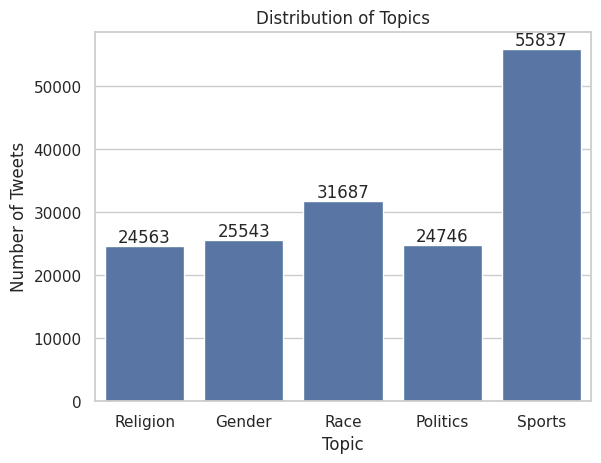

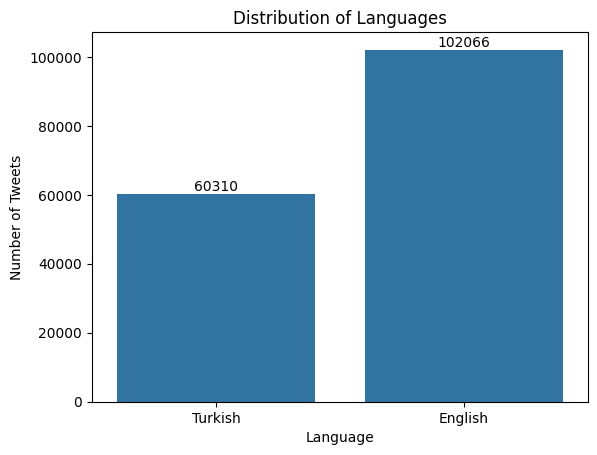

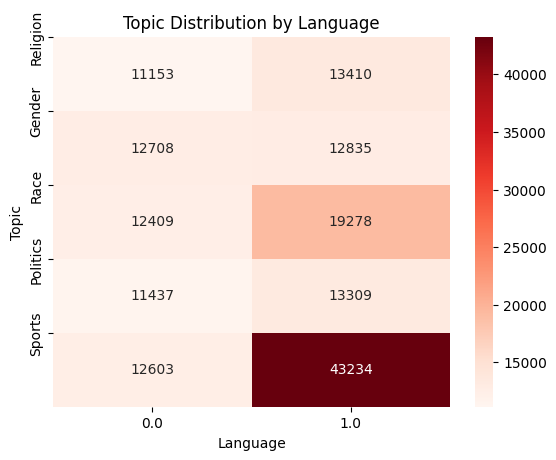

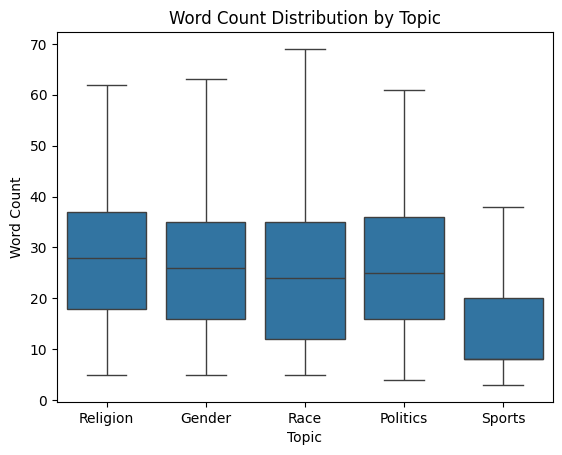

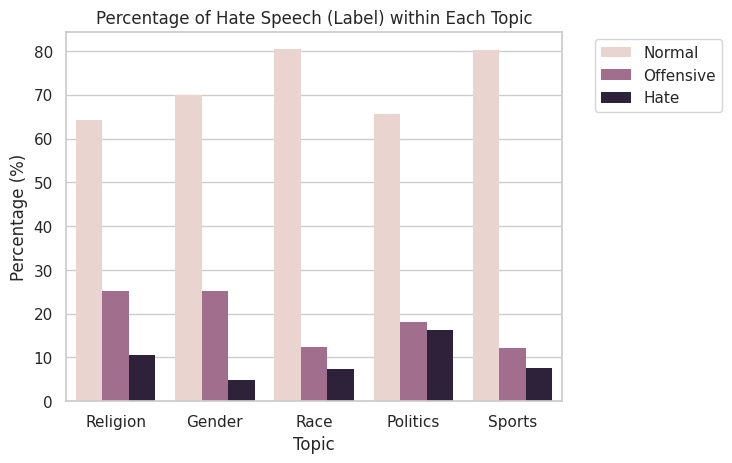

In [ ]:
topics = ['Religion', 'Gender', 'Race', 'Politics', 'Sports']

# dist topic
sns.set_theme(style="whitegrid")
ax1 = sns.countplot(x='topic', data=df)
plt.xlabel('Topic')
plt.ylabel('Number of Tweets')
plt.title('Distribution of Topics')
plt.xticks(np.arange(5), topics)
plt.bar_label(ax1.containers[0])
plt.show()

# dist lang
sns.reset_orig()
ax2 = sns.countplot(x='language', data=df)
plt.xlabel('Language')
plt.ylabel('Number of Tweets')
plt.title('Distribution of Languages')
plt.xticks(np.arange(2), ['Turkish', 'English'])
plt.bar_label(ax2.containers[0])
plt.show()

# hmap topic-lang
hmap_df = pd.crosstab(df['topic'], df['language'])
sns.heatmap(hmap_df, annot=True, fmt='d', cmap='Reds')
plt.xlabel('Language')
plt.ylabel('Topic')
plt.title('Topic Distribution by Language')
plt.yticks(np.arange(5), topics)
plt.show()

# boxplot topic-word_count
sns.boxplot(x='topic', y='word_count', data=df, showfliers=False) # removed outliers, sports has a lot and gender has a single way above
plt.xlabel('Topic')
plt.ylabel('Word Count')
plt.title('Word Count Distribution by Topic')
plt.xticks(np.arange(5), topics)
plt.show()

# percentage of hate per topic
plot_df = (df.groupby('topic')['label']
             .value_counts(normalize=True)
             .mul(100)
             .rename('percentage')
             .reset_index())
sns.set_theme(style="whitegrid")
ax = sns.barplot(
    data=plot_df,
    x='topic',
    y='percentage',
    hue='label',
    #palette='deep',
    hue_order=['Normal', 'Offensive', 'Hate'],
    edgecolor='none'
)

plt.title('Percentage of Hate Speech (Label) within Each Topic')
plt.xlabel('Topic')
plt.ylabel('Percentage (%)')
plt.legend(title='Hate Speech Label', bbox_to_anchor=(1.05, 1), loc='upper left', labels=['Normal', 'Offensive', 'Hate'])

handles, labels = ax.get_legend_handles_labels()

for handle in handles:
    handle.set_linewidth(0)
    handle.set_edgecolor('none')

plt.legend(
    handles=handles,
    labels=['Normal', 'Offensive', 'Hate'],
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.xticks(np.arange(5), topics)
plt.show()

sns.reset_orig()

# Stemming

In [ ]:
tr_stemmer = TurkishStemmer()
eng_stemmer = SnowballStemmer('english')

stopwords_tr = set(stopwords.words('turkish'))
stopwords_en = set(stopwords.words('english'))

def preprocess_text(row, use_stemming=False):
    text = row['text']
    lang = row['language']

    text = str(text).lower()
    text = re.sub(r'[^a-zA-ZçğıöşüÇĞİÖŞÜ\s]', '', text)
    tokens = text.split()

    if lang == 0.0: # Turkish
        tokens = [t for t in tokens if t not in stopwords_tr]
        if use_stemming:
            tokens = [tr_stemmer.stem(t) for t in tokens]

    elif lang == 1.0: # English
        tokens = [t for t in tokens if t not in stopwords_en]
        if use_stemming:
            tokens = [eng_stemmer.stem(t) for t in tokens]

    return " ".join(tokens)

# Preprocessing

In [ ]:
print("Preprocessing data")
df['text_no_stem'] = df.apply(lambda row: preprocess_text(row, use_stemming=False), axis=1)
df['text_stemmed'] = df.apply(lambda row: preprocess_text(row, use_stemming=True), axis=1)
print("Preprocessing complete")

Preprocessing data
Preprocessing complete


# Models

In [ ]:
configurations = [
    ("No Stemming", "text_no_stem", CountVectorizer(), "Count Vectorizer"),
    ("No Stemming", "text_no_stem", TfidfVectorizer(), "TF-IDF"),
    ("With Stemming", "text_stemmed", CountVectorizer(), "Count Vectorizer"),
    ("With Stemming", "text_stemmed", TfidfVectorizer(), "TF-IDF"),
]

models = {
    "MultinomialNB": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=20, random_state=42, n_jobs=-1),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

results = []

print(f"Testing on {len(df)} samples")

df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
y_train = df_train['topic']
y_test = df_test['topic']

print(f"{len(df_train)} train samples, {len(df_test)} test samples")
print("-" * 60)

for stem_label, col_name, vectorizer, vec_label in configurations:
    print(f"Processing config: {stem_label} + {vec_label}")

    X_train = vectorizer.fit_transform(df_train[col_name])
    X_test = vectorizer.transform(df_test[col_name])

    for model_name, model_instance in models.items():
        model = clone(model_instance)

        print(f"   Training {model_name}")

        # training speed
        start_train = time.time()
        model.fit(X_train, y_train)
        end_train = time.time()
        train_time = end_train - start_train

        # prediction speed
        start_pred = time.time()
        y_pred = model.predict(X_test)
        end_pred = time.time()
        pred_time = end_pred - start_pred

        # metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
        cm = confusion_matrix(y_test, y_pred)

        results.append({
            'Algorithm': model_name,
            'Stemming': stem_label,
            'Feature_Type': vec_label,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1_Score': f1,
            'Train_Time_Sec': train_time,
            'Predict_Time_Sec': pred_time,
            'Confusion_Matrix': cm
        })

print("\nTesting finished")

Testing on 162376 samples
Global Split Created: 129900 train samples, 32476 test samples
------------------------------------------------------------
Processing config: No Stemming + Count Vectorizer
   Training MultinomialNB
   Training Random Forest
   Training Logistic Regression
Processing config: No Stemming + TF-IDF
   Training MultinomialNB
   Training Random Forest
   Training Logistic Regression
Processing config: With Stemming + Count Vectorizer
   Training MultinomialNB
   Training Random Forest
   Training Logistic Regression
Processing config: With Stemming + TF-IDF
   Training MultinomialNB
   Training Random Forest
   Training Logistic Regression

Testing finished


# Results

Algorithm,Stemming,Feature_Type,Accuracy,Precision,Recall,F1_Score,Train_Time_Sec,Predict_Time_Sec,Config_Label
Logistic Regression,No Stemming,Count Vectorizer,96.10%,95.45%,95.49%,95.43%,31.3522 s,0.0213 s,No Stemming Count Vectorizer
Logistic Regression,No Stemming,TF-IDF,95.86%,95.18%,95.19%,95.15%,62.3726 s,0.0206 s,No Stemming TF-IDF
Logistic Regression,With Stemming,Count Vectorizer,95.73%,95.00%,95.07%,95.00%,28.0103 s,0.0153 s,With Stemming Count Vectorizer
Logistic Regression,With Stemming,TF-IDF,95.67%,94.94%,94.95%,94.92%,38.8042 s,0.0201 s,With Stemming TF-IDF
MultinomialNB,No Stemming,Count Vectorizer,90.09%,88.40%,88.41%,88.30%,0.0973 s,0.0145 s,No Stemming Count Vectorizer
MultinomialNB,With Stemming,Count Vectorizer,89.56%,87.71%,87.86%,87.68%,0.0759 s,0.0136 s,With Stemming Count Vectorizer
MultinomialNB,No Stemming,TF-IDF,88.79%,87.73%,86.22%,86.73%,0.0681 s,0.0118 s,No Stemming TF-IDF
MultinomialNB,With Stemming,TF-IDF,88.51%,87.14%,86.03%,86.37%,0.0591 s,0.0098 s,With Stemming TF-IDF
Random Forest,With Stemming,Count Vectorizer,41.22%,82.75%,26.98%,22.80%,9.3893 s,0.1813 s,With Stemming Count Vectorizer
Random Forest,With Stemming,TF-IDF,41.16%,83.63%,26.96%,22.86%,8.3828 s,0.2014 s,With Stemming TF-IDF


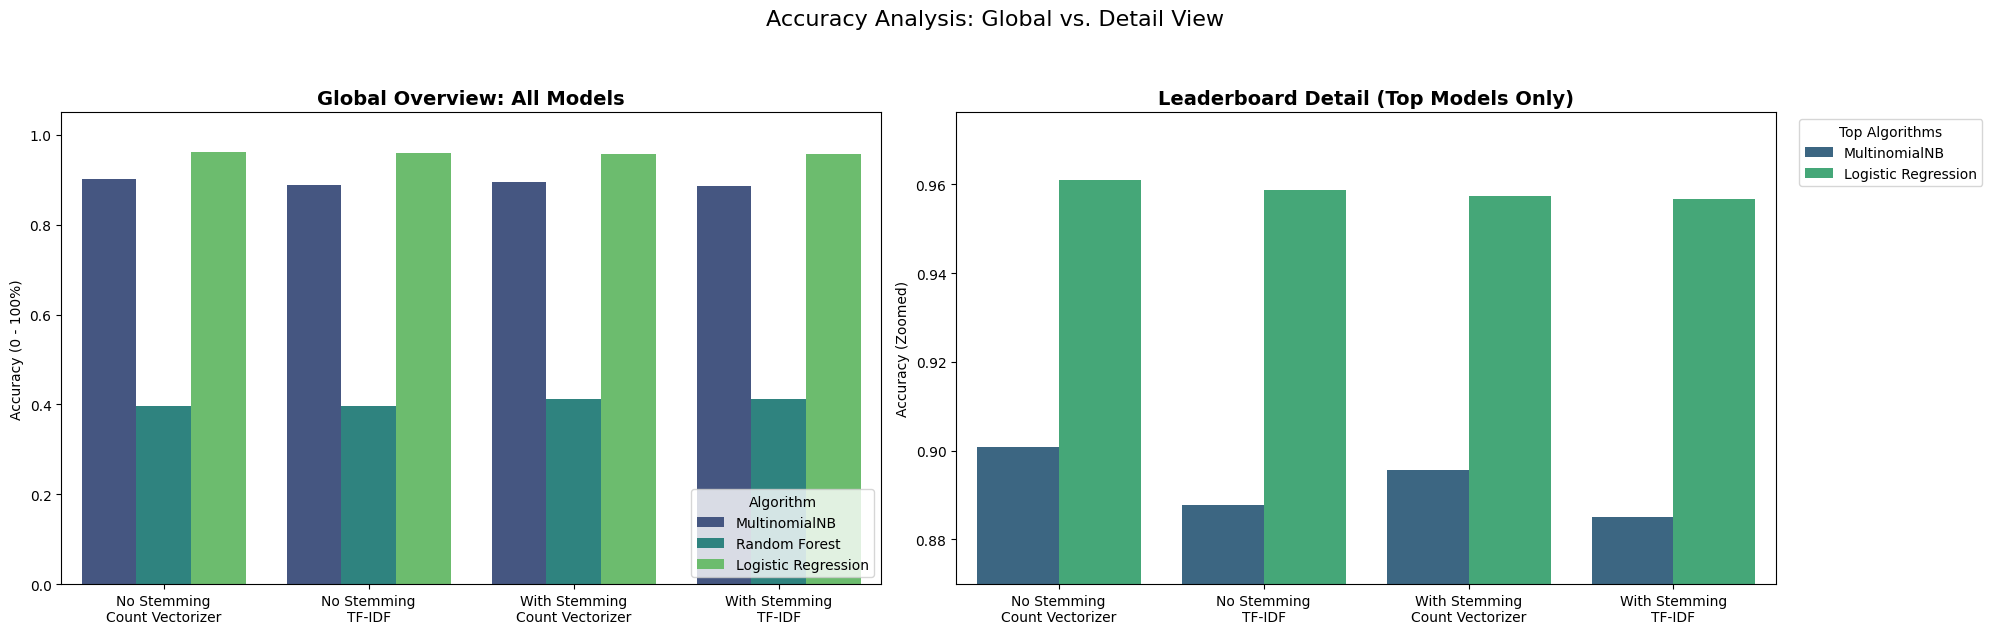

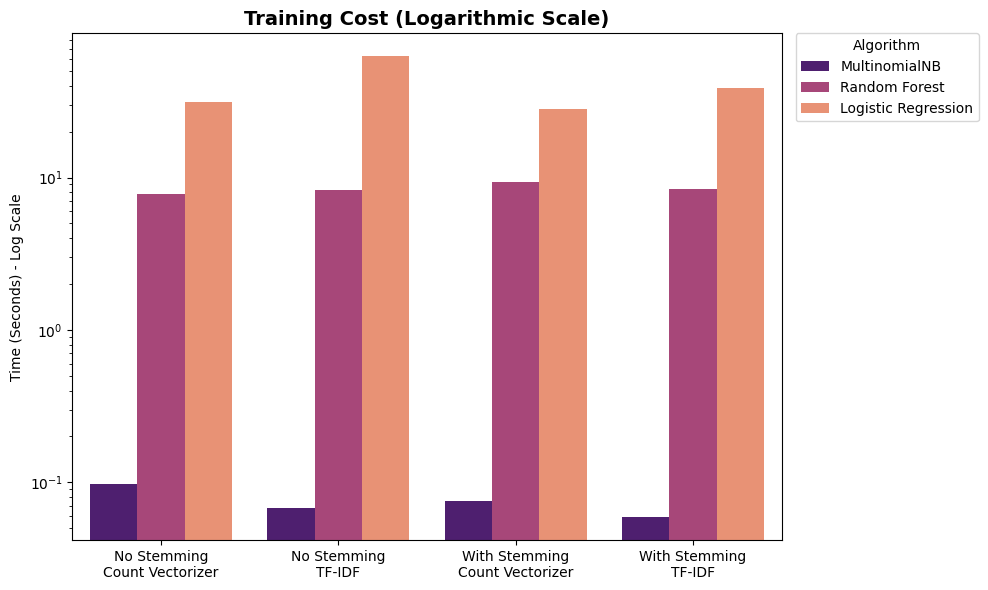

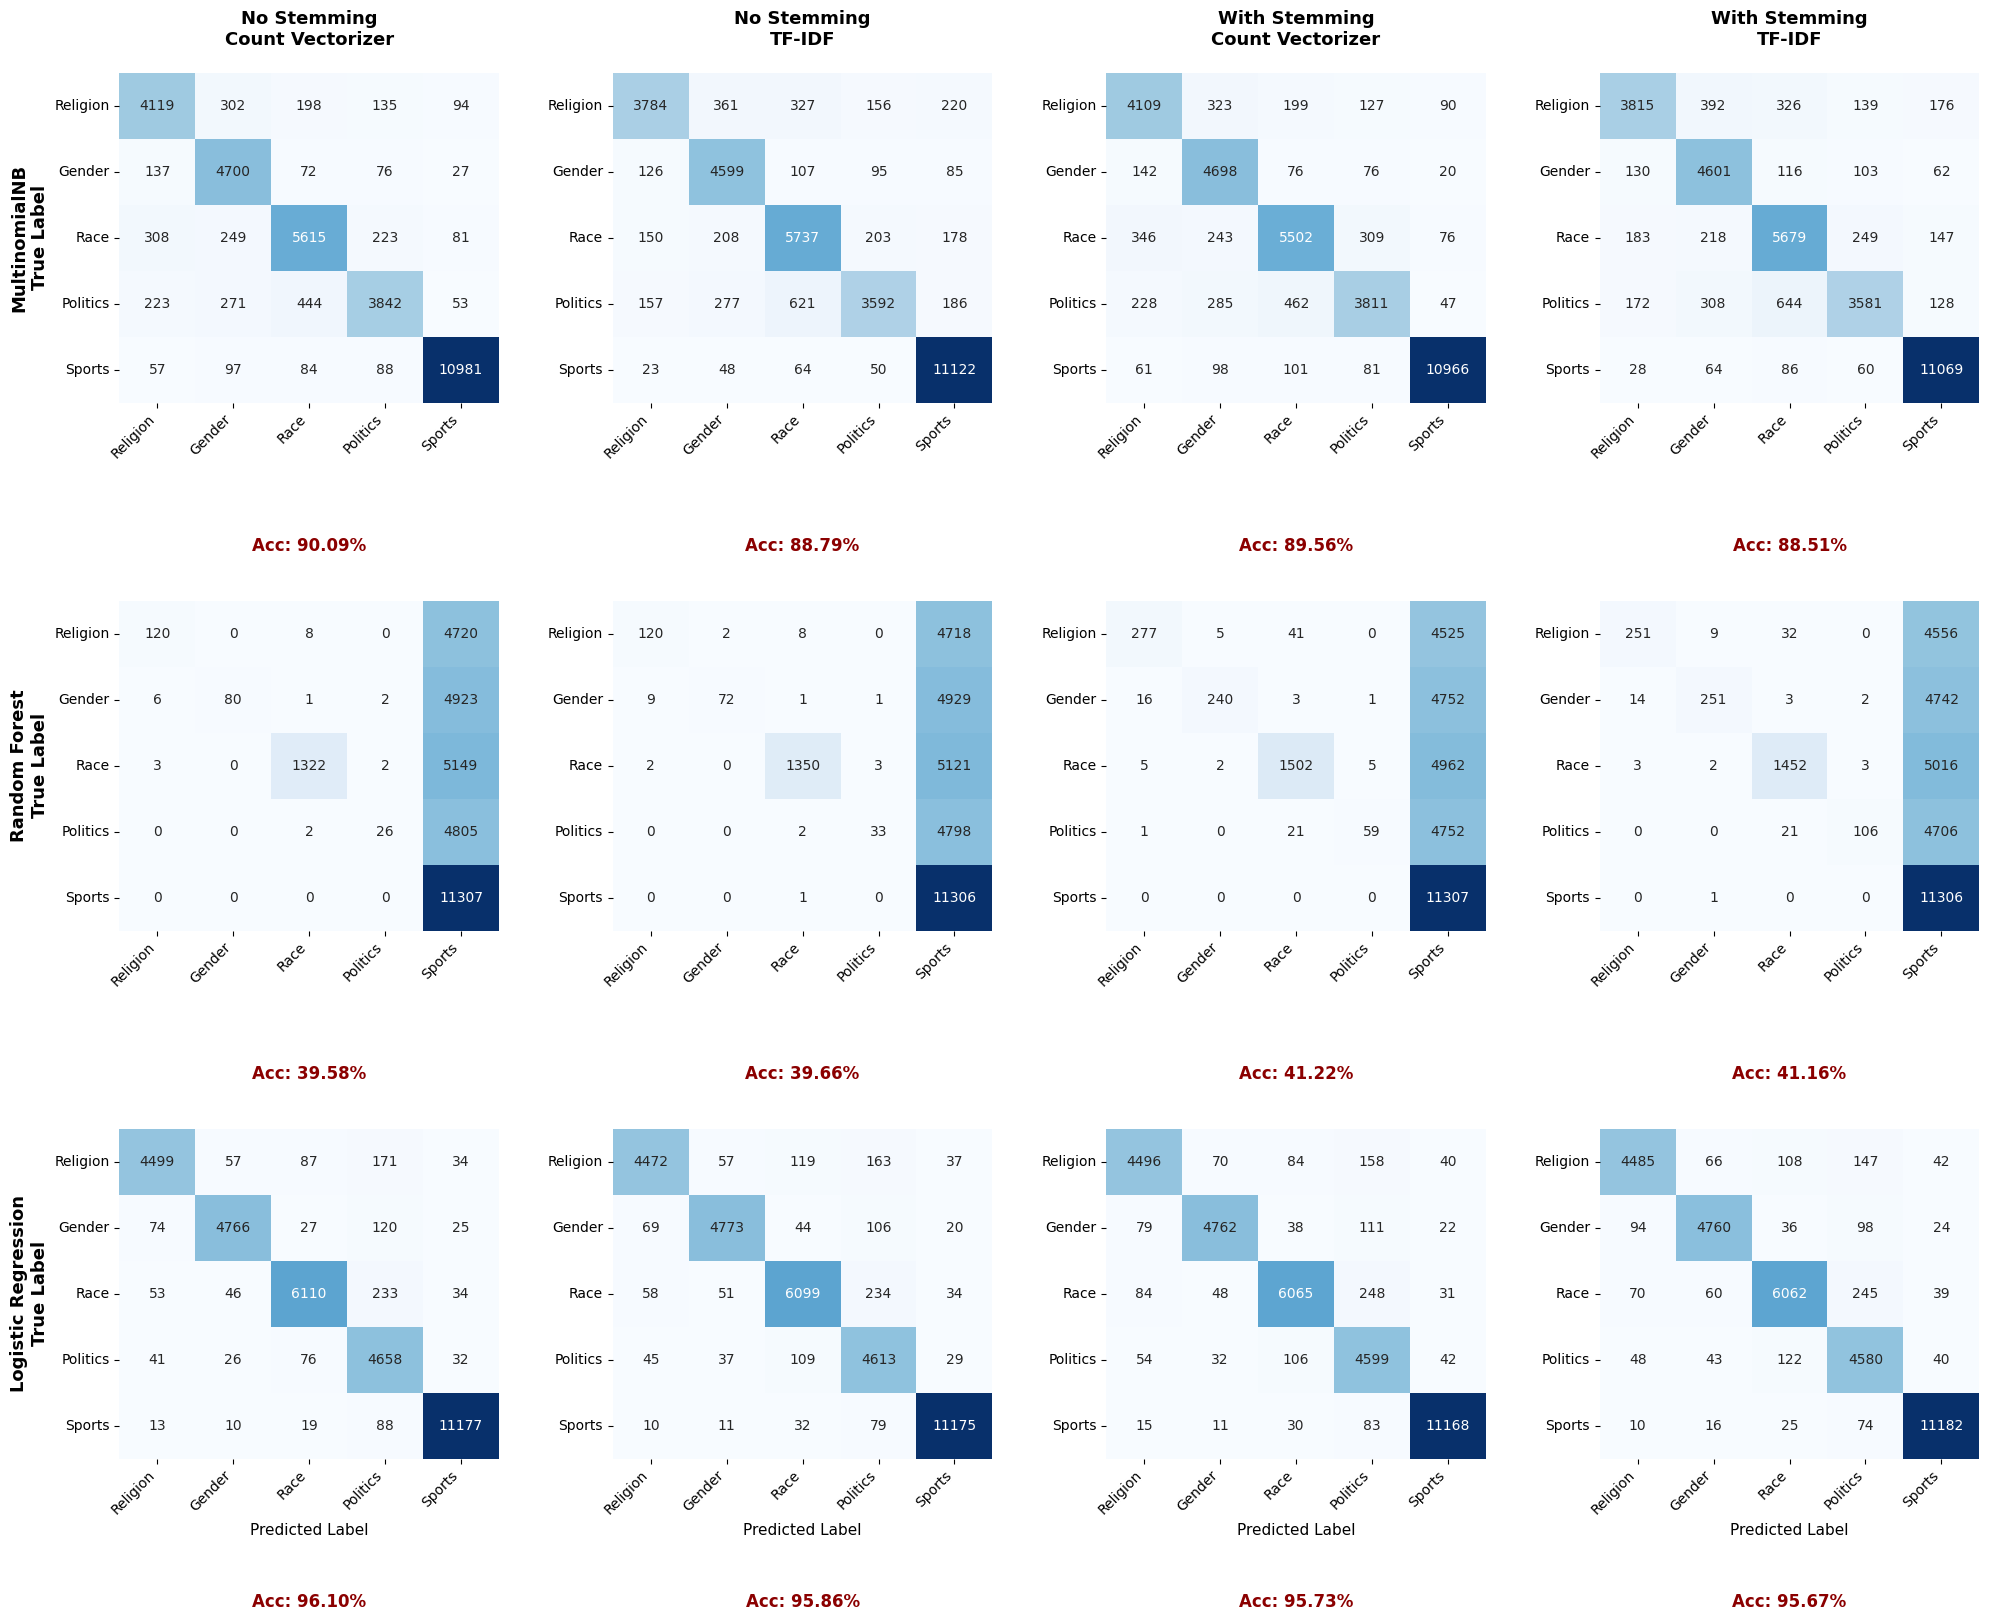

In [ ]:
results_df = pd.DataFrame(results)
results_df['Config_Label'] = results_df['Stemming'] + "\n" + results_df['Feature_Type']

model_order = ["MultinomialNB", "Random Forest", "Logistic Regression"]
config_order = sorted(results_df['Config_Label'].unique())
topic_labels = ['Religion', 'Gender', 'Race', 'Politics', 'Sports']

# summary table
summary_df = results_df.drop(columns=['Confusion_Matrix']).copy()
summary_df = summary_df.sort_values(by='Accuracy', ascending=False)

format_dict = {
    'Accuracy': '{:.2%}',
    'Precision': '{:.2%}',
    'Recall': '{:.2%}',
    'F1_Score': '{:.2%}',
    'Train_Time_Sec': '{:.4f} s',
    'Predict_Time_Sec': '{:.4f} s'
}

display(summary_df.style.background_gradient(cmap='Greens', subset=['Accuracy', 'F1_Score'])
                 .format(format_dict)
                 .hide(axis='index'))

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# global accuracy
sns.barplot(data=results_df, x='Config_Label', y='Accuracy', hue='Algorithm',
            hue_order=model_order, ax=axes[0], palette='viridis')
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Global Overview: All Models", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Accuracy (0 - 100%)")
axes[0].set_xlabel("")
axes[0].legend(loc='lower right', title="Algorithm")
axes[0].tick_params(axis='x', rotation=0)

# zoomed accuracy
top_performers = results_df[results_df['Algorithm'] != "Random Forest"]
if not top_performers.empty:
    sns.barplot(data=top_performers, x='Config_Label', y='Accuracy', hue='Algorithm',
                hue_order=["MultinomialNB", "Logistic Regression"],
                ax=axes[1], palette='viridis')
    min_acc = top_performers['Accuracy'].min()
    max_acc = top_performers['Accuracy'].max()
    margin = (max_acc - min_acc) * 0.2
    axes[1].set_ylim(max(0, min_acc - margin), min(1.0, max_acc + margin))
    axes[1].set_title("Leaderboard Detail (Top Models Only)", fontsize=14, fontweight='bold')
    axes[1].set_ylabel("Accuracy (Zoomed)")
    axes[1].set_xlabel("")
    axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Top Algorithms")
    axes[1].tick_params(axis='x', rotation=0)

plt.suptitle("Accuracy Analysis: Global vs. Detail View", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# training time plot
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Config_Label', y='Train_Time_Sec', hue='Algorithm',
            hue_order=model_order, palette='magma')
plt.yscale('log')
plt.title("Training Cost (Logarithmic Scale)", fontsize=14, fontweight='bold')
plt.ylabel("Time (Seconds) - Log Scale")
plt.xlabel("")
plt.legend(title="Algorithm", bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# confusion matrix
n_rows = len(model_order)
n_cols = len(config_order)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 18))
plt.subplots_adjust(hspace=0.6, wspace=0.3)

for row_idx, model_name in enumerate(model_order):
    for col_idx, config_name in enumerate(config_order):
        ax = axes[row_idx, col_idx]

        subset = results_df[
            (results_df['Algorithm'] == model_name) &
            (results_df['Config_Label'] == config_name)
        ]

        if not subset.empty:
            cm = subset.iloc[0]['Confusion_Matrix']
            acc = subset.iloc[0]['Accuracy']

            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)

            ax.set_xticklabels(topic_labels, rotation=45, ha='right', fontsize=10)
            ax.set_yticklabels(topic_labels, rotation=0, fontsize=10)

            if col_idx == 0:
                ax.set_ylabel(f"{model_name}\nTrue Label", fontsize=13, fontweight='bold')
            else:
                ax.set_ylabel("")

            if row_idx == 0:
                ax.set_title(config_name, fontsize=13, fontweight='bold', pad=20)

            if row_idx == n_rows - 1:
                ax.set_xlabel("Predicted Label", fontsize=11)
            else:
                ax.set_xlabel("")

            ax.text(0.5, -0.45, f"Acc: {acc:.2%}", transform=ax.transAxes,
                    ha='center', color='darkred', fontweight='bold', fontsize=12)

plt.show()
